In [13]:
import sympy
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
from evolml.models import *
from sklearn.metrics import r2_score, roc_auc_score
import numpy as np
%matplotlib inline

# Explicit expression classifier

In [14]:
X = np.linspace(-1, 1, 1000).reshape([-1, 1])
y_c = ((4*X**2 + X - 1) > 0).astype(int)
y_r = (4*X**2 + X - 1)

X_train, X_test = X[::2], X[1::2]
y_c_train, y_c_test = y_c[::2], y_c[1::2]
y_r_train, y_r_test = y_r[::2], y_r[1::2]

X_train.shape, X_test.shape, y_c_train.shape, y_c_test.shape

((500, 1), (500, 1), (500, 1), (500, 1))

In [16]:
model = ExplicitPSClassifier("p_0 * x_0**2 + p_1 * x_0 + p_2")

model = model.fit(X_train, y_c_train)

Initializing optimization of Symbolic regression using PSO
----------------------------------------------------------

Optimizing Symbolic regression using PSO:
	Real time Spent: 0.36 s
	CPU time Spent:  0.36 s
	Generation: 0
	Best fitness: 0.794
	Evaluations of fitness: 100

	diversity: 43.2
	mean speed: 0.492

Optimizing Symbolic regression using PSO:
	Real time Spent: 0.71 s
	CPU time Spent:  0.71 s
	Generation: 1
	Best fitness: 0.984
	Evaluations of fitness: 200

	diversity: 27.6
	mean speed: 8.36

Optimizing Symbolic regression using PSO:
	Real time Spent: 1.34 s
	CPU time Spent:  1.34 s
	Generation: 3
	Best fitness: 0.984
	Evaluations of fitness: 400

	diversity: 49.3
	mean speed: 9.82

Optimizing Symbolic regression using PSO:
	Real time Spent: 1.92 s
	CPU time Spent:  1.92 s
	Generation: 5
	Best fitness: 0.99
	Evaluations of fitness: 600

	diversity: 42.1
	mean speed: -0.318

Optimizing Symbolic regression using PSO:
	Real time Spent: 2.56 s
	CPU time Spent:  2.56 s
	Generation

In [17]:
y_pred = model.predict(X_test)
roc_auc_score(y_pred, y_c_test)

np.float64(0.998062015503876)

In [18]:
print("Resulting Equation:")
eq = model.objfunc.decision_boundary().subs(zip(model.objfunc.curve_params, model.parameters))
display(eq)

Resulting Equation:


Eq(70.9076295551713*x_0**2 + 18.015989680516*x_0 - 17.7735856939751, 0)

x_0 x_1


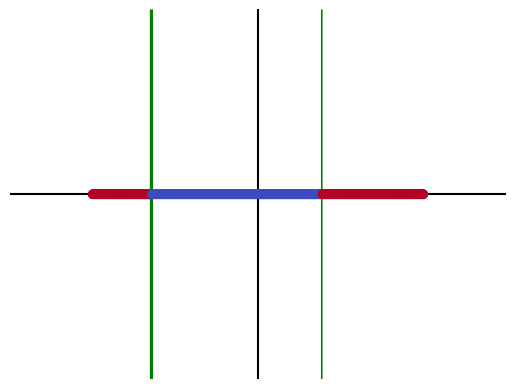

In [19]:
eq = model.objfunc.decision_boundary().subs(zip(model.objfunc.curve_params, model.parameters))
x, y = sympy.symbols("x_0 x_1")
print(x, y)

p = sympy.plot_implicit(eq, x, y, show=False, line_color="green", adaptive=True, axis=False)
p._backend.process_series()
plt_fig = p._backend.fig
plt_ax = p._backend.ax
plt_ax.scatter(X, X*0, c=y_c, cmap="coolwarm", zorder=2)
plt_ax.axvline(0, color="black", zorder=-1)
plt_ax.axhline(0, color="black", zorder=-1)
plt.xlim(-1.5, 1.5)
plt.show()

# Explicit function regression

In [20]:
model = ExplicitPSRegressor("p_0 * x_0**2 + p_1 + x_0 + p_2")

model = model.fit(X_train, y_r_train)

Initializing optimization of Symbolic regression using PSO
----------------------------------------------------------

Optimizing Symbolic regression using PSO:
	Real time Spent: 0.28 s
	CPU time Spent:  0.28 s
	Generation: 0
	Best fitness: 28.436662185745988
	Evaluations of fitness: 100

	diversity: 41.7
	mean speed: 0.515

Optimizing Symbolic regression using PSO:
	Real time Spent: 0.55 s
	CPU time Spent:  0.55 s
	Generation: 1
	Best fitness: 6.476412669920972
	Evaluations of fitness: 200

	diversity: 23.8
	mean speed: 0.855

Optimizing Symbolic regression using PSO:
	Real time Spent: 1.12 s
	CPU time Spent:  1.12 s
	Generation: 3
	Best fitness: 0.7212737462222655
	Evaluations of fitness: 400

	diversity: 21.4
	mean speed: 1.02

Optimizing Symbolic regression using PSO:
	Real time Spent: 1.66 s
	CPU time Spent:  1.66 s
	Generation: 5
	Best fitness: 0.19672256962864798
	Evaluations of fitness: 600

	diversity: 17.7
	mean speed: -3.42

Optimizing Symbolic regression using PSO:
	Real ti

In [21]:
y_pred = model.predict(X_test)
r2_score(y_pred, y_r_test)

1.0

In [22]:
print("Resulting Equation:")
eq = model.objfunc.decision_boundary().subs(zip(model.objfunc.curve_params, model.parameters))
display(eq)

Resulting Equation:


Eq(4.00000000000003*x_0**2 + x_0 - 1.00000000000001, x_1)

x_0 x_1


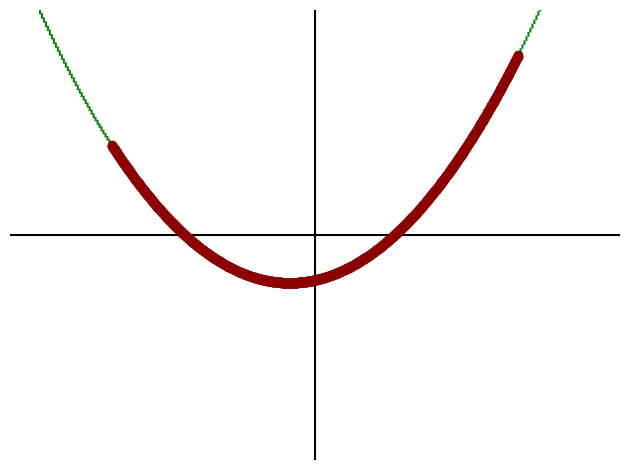

In [23]:
eq = model.objfunc.decision_boundary().subs(zip(model.objfunc.curve_params, model.parameters))
x, y = sympy.symbols("x_0 x_1")
print(x, y)

p = sympy.plot_implicit(eq, x, y, show=False, line_color="green", adaptive=True, axis=False)
p._backend.process_series()
plt_fig = p._backend.fig
plt_ax = p._backend.ax
plt_ax.scatter(X, y_r, c="darkred", zorder=2)
plt_ax.axvline(0, color="black", zorder=-1)
plt_ax.axhline(0, color="black", zorder=-1)
plt_ax.set_xlim(-1.5, 1.5)
plt_fig.tight_layout()
plt.show()
